<a href="https://colab.research.google.com/github/VISHWAJA-028/ML_Multimodality/blob/main/ML_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
# Run once per Colab session
!pip install xgboost lightgbm shap -q

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report,
                              roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sns.set_style("whitegrid")
RANDOM_STATE = 42

In [26]:
# Option A: direct upload
from google.colab import files
uploaded = files.upload()   # choose pocs_final.xlsx
FILE_PATH = list(uploaded.keys())[0]

# Option B: Google Drive (comment out Option A and use this instead)
# from google.colab import drive
# drive.mount('/content/drive')
# FILE_PATH = '/content/drive/MyDrive/PCOS/pocs_final.xlsx'

df = pd.read_excel(FILE_PATH)
print(df.shape)
df.head()

Saving pocs_final.xlsx to pocs_final (1).xlsx
(3556, 45)


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Source_Dataset
0,1,P-10000,0,30,69.979147,167.708055,23.185569,12,72,22,...,0.0,1,105.483401,76.096379,2,4,10.0,13.0,6.176029,NaN
1,2,P-10001,0,36,63.711688,154.055877,25.441392,13,70,18,...,0.0,1,115.883740,79.117243,2,3,13.0,11.0,6.824718,NaN
2,3,P-10002,0,36,51.848631,149.059804,23.928264,15,80,20,...,0.0,0,112.219711,80.919417,1,1,14.0,17.0,2.568691,NaN
3,4,P-10003,1,29,66.893988,148.628036,27.894935,15,72,18,...,0.0,1,104.619624,69.902681,1,1,12.0,14.0,9.962732,NaN
4,5,P-10004,0,33,52.536198,150.767409,23.079564,13,72,18,...,0.0,0,99.175454,70.330461,5,2,11.5,4.7,6.655190,NaN


In [27]:
df_clean = df.copy()

# --- Target: unify PCOS (Y/N) to 0/1 ---
target_map = {0: 0, 1: 1, '0': 0, '1': 1, 'N': 0, 'Y': 1, 'n': 0, 'y': 1}
df_clean['PCOS (Y/N)'] = df_clean['PCOS (Y/N)'].map(target_map)
assert df_clean['PCOS (Y/N)'].isna().sum() == 0, "Unmapped target values found!"
df_clean['PCOS (Y/N)'] = df_clean['PCOS (Y/N)'].astype(int)

# --- Blood Group: unify numeric codes with letter codes ---
# Standard PCOS-dataset code scheme: 11=A+ 12=A- 13=B+ 14=B- 15=O+ 16=O- 17=AB+ 18=AB-
bg_code_map = {
    '11': 'A+', '12': 'A-', '13': 'B+', '14': 'B-',
    '15': 'O+', '16': 'O-', '17': 'AB+', '18': 'AB-'
}
df_clean['Blood Group'] = df_clean['Blood Group'].astype(str).str.strip()
df_clean['Blood Group'] = df_clean['Blood Group'].replace(bg_code_map)
print(df_clean['Blood Group'].value_counts())

# --- Cycle(R/I): unify numeric codes with letters ---
# Standard scheme: 2 = Regular (R), 4 = Irregular (I). Any other stray code -> NaN (imputed later)
cycle_map = {'2': 'R', '4': 'I', 'R': 'R', 'I': 'I'}
df_clean['Cycle(R/I)'] = df_clean['Cycle(R/I)'].astype(str).str.strip().map(cycle_map)
print(df_clean['Cycle(R/I)'].value_counts(dropna=False))

# --- AMH(ng/mL): strip bad entries, coerce to numeric ---
df_clean['AMH(ng/mL)'] = pd.to_numeric(df_clean['AMH(ng/mL)'], errors='coerce')

# --- II beta-HCG(mIU/mL): fix malformed numbers like '1.99.' then coerce ---
def fix_double_decimal(x):
    s = str(x)
    if s.count('.') > 1:
        first_dot = s.index('.')
        s = s[:first_dot+1] + s[first_dot+1:].replace('.', '')
    return s

df_clean['II beta-HCG(mIU/mL)'] = df_clean['II beta-HCG(mIU/mL)'].apply(fix_double_decimal)
df_clean['II beta-HCG(mIU/mL)'] = pd.to_numeric(df_clean['II beta-HCG(mIU/mL)'], errors='coerce')

# --- Drop empty / identifier columns (keep Patient File No. aside as a join key) ---
patient_ids = df_clean['Patient File No.']
df_clean = df_clean.drop(columns=['Source_Dataset', 'Sl. No', 'Patient File No.'])

print("\nRemaining missing values after targeted fixes:")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])

Blood Group
O+     1233
B+      920
A+      691
AB+     332
O-      141
B-      108
A-       97
AB-      34
Name: count, dtype: int64
Cycle(R/I)
R      2256
I      1297
NaN       3
Name: count, dtype: int64

Remaining missing values after targeted fixes:
Cycle(R/I)    3
AMH(ng/mL)    3
dtype: int64


In [28]:
# --- Standardize remaining Y/N categorical columns to 0/1 ---
yn_cols = [c for c in df_clean.columns if '(Y/N)' in c and c != 'PCOS (Y/N)']
for c in yn_cols:
    df_clean[c] = df_clean[c].astype(str).str.strip().str.upper().map({'Y': 1, 'N': 0, '1': 1, '0': 0})

print(df_clean[yn_cols].isna().sum())

Pregnant(Y/N)              0
Weight gain(Y/N)           0
hair growth(Y/N)           0
Skin darkening (Y/N)       0
Hair loss(Y/N)             0
Pimples(Y/N)               0
Fast food (Y/N)         2000
Reg.Exercise(Y/N)          0
dtype: int64


PCOS (Y/N)
0    0.701912
1    0.298088
Name: proportion, dtype: float64


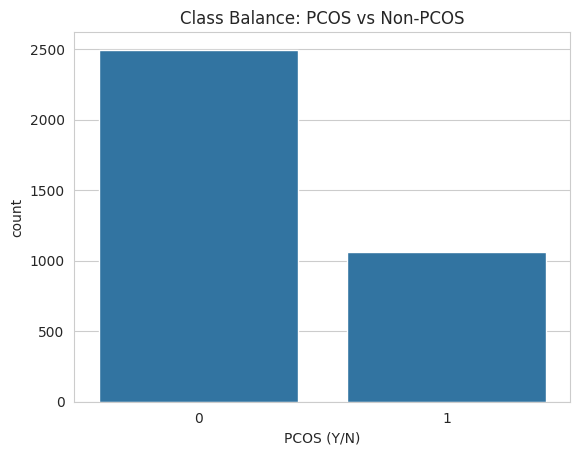

In [29]:
print(df_clean['PCOS (Y/N)'].value_counts(normalize=True))
sns.countplot(x='PCOS (Y/N)', data=df_clean)
plt.title('Class Balance: PCOS vs Non-PCOS')
plt.show()

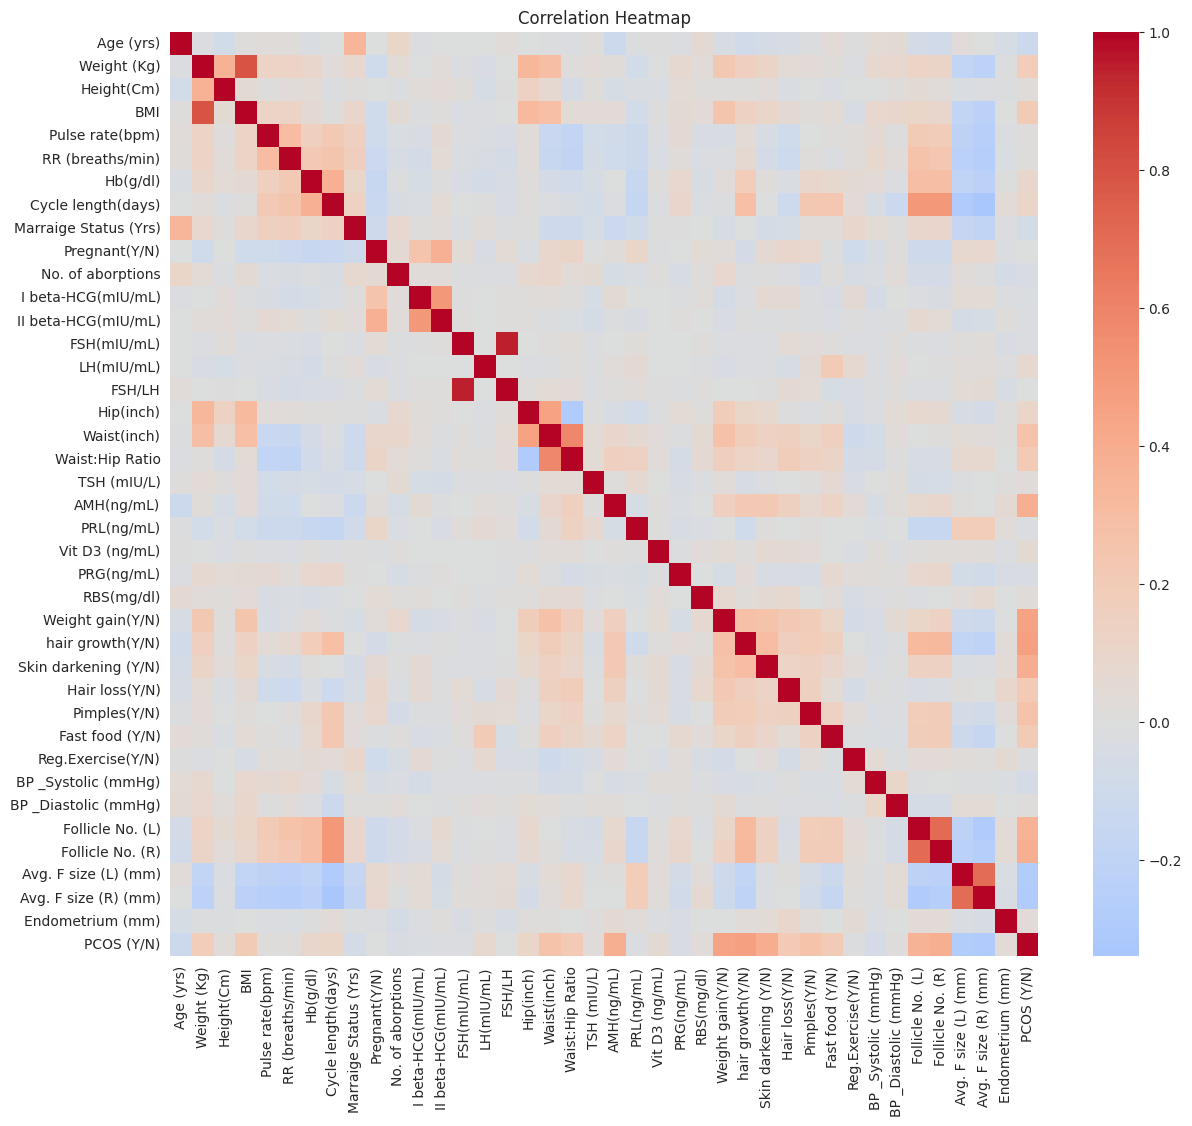

PCOS (Y/N)              1.000000
hair growth(Y/N)        0.464226
Weight gain(Y/N)        0.447333
Skin darkening (Y/N)    0.397522
Follicle No. (R)        0.384600
AMH(ng/mL)              0.383950
Follicle No. (L)        0.360735
Avg. F size (R) (mm)    0.287213
Avg. F size (L) (mm)    0.273029
Pimples(Y/N)            0.260783
Waist(inch)             0.259186
Waist:Hip Ratio         0.209984
Hair loss(Y/N)          0.207045
BMI                     0.197100
Fast food (Y/N)         0.196359
Name: PCOS (Y/N), dtype: float64


In [30]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('PCOS (Y/N)')

plt.figure(figsize=(14, 12))
sns.heatmap(df_clean[numeric_cols + ['PCOS (Y/N)']].corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

# Top correlated features with target
corr_with_target = df_clean[numeric_cols + ['PCOS (Y/N)']].corr()['PCOS (Y/N)'].abs().sort_values(ascending=False)
print(corr_with_target.head(15))

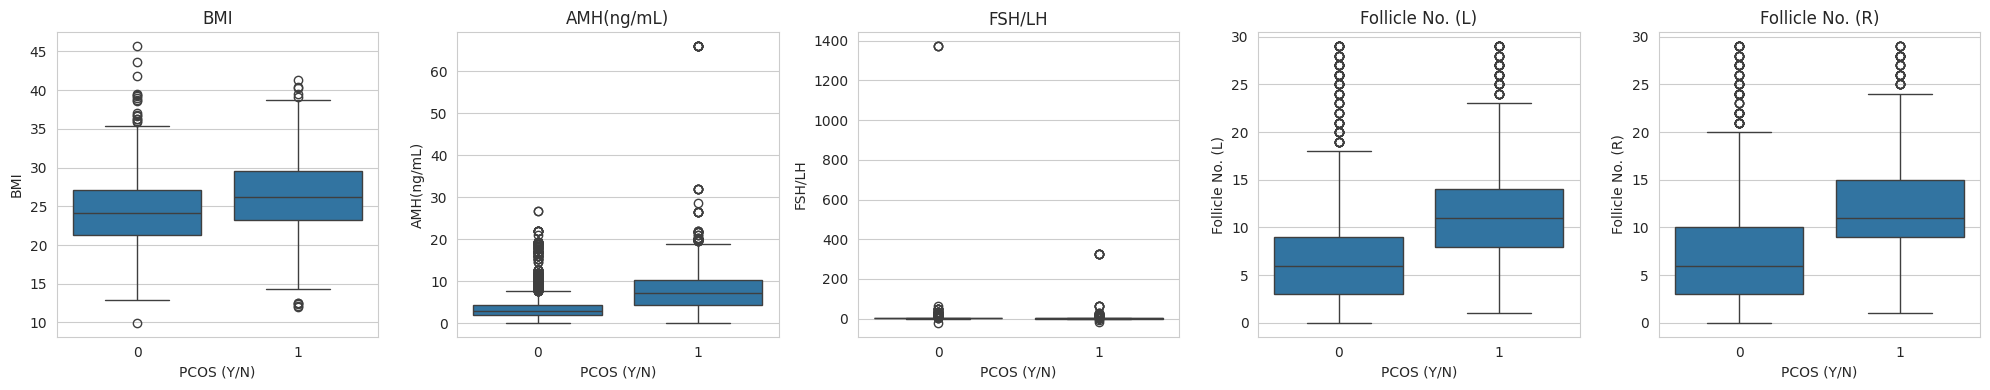

In [31]:
key_features = ['BMI', 'AMH(ng/mL)', 'FSH/LH', 'Follicle No. (L)', 'Follicle No. (R)']
fig, axes = plt.subplots(1, len(key_features), figsize=(20, 4))
for ax, feat in zip(axes, key_features):
    sns.boxplot(x='PCOS (Y/N)', y=feat, data=df_clean, ax=ax)
    ax.set_title(feat)
plt.tight_layout()
plt.show()

**Basic dataset information**

In [32]:
df_fe = df_clean.copy()

df_fe['Follicle_Total'] = df_fe['Follicle No. (L)'] + df_fe['Follicle No. (R)']
df_fe['Avg_F_Size_Mean'] = df_fe[['Avg. F size (L) (mm)', 'Avg. F size (R) (mm)']].mean(axis=1)

def bmi_category(bmi):
    if bmi < 18.5: return 'Underweight'
    elif bmi < 25: return 'Normal'
    elif bmi < 30: return 'Overweight'
    else: return 'Obese'

df_fe['BMI_Category'] = df_fe['BMI'].apply(bmi_category)

df_fe = pd.get_dummies(df_fe, columns=['Blood Group', 'Cycle(R/I)', 'BMI_Category'], dummy_na=True)

print(df_fe.shape)
df_fe.head()


(3556, 59)


,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle length(days),Marraige Status (Yrs),...,Blood Group_O-,Blood Group_nan,Cycle(R/I)_I,Cycle(R/I)_R,Cycle(R/I)_nan,BMI_Category_Normal,BMI_Category_Obese,BMI_Category_Overweight,BMI_Category_Underweight,BMI_Category_nan
0,0,30,69.979147,167.708055,23.185569,72,22,12.0,5,10.0,...,False,False,True,False,False,True,False,False,False,False
1,0,36,63.711688,154.055877,25.441392,70,18,10.5,6,12.0,...,False,False,False,True,False,False,False,True,False,False
2,0,36,51.848631,149.059804,23.928264,80,20,10.0,2,4.0,...,False,False,True,False,False,True,False,False,False,False
3,1,29,66.893988,148.628036,27.894935,72,18,12.0,5,9.0,...,False,False,True,False,False,False,False,True,False,False
4,0,33,52.536198,150.767409,23.079564,72,18,10.2,5,9.0,...,False,False,False,True,False,True,False,False,False,False


In [33]:
import re

# Clean column names for LightGBM compatibility
def clean_col_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        # Replace non-alphanumeric characters (except underscore) with underscore
        new_col = re.sub(r'[^A-Za-z0-9_]', '_', col)
        # Replace multiple underscores with a single underscore
        new_col = re.sub(r'_{2,}', '_', new_col)
        # Strip leading/trailing underscores
        new_col = new_col.strip('_')
        new_cols.append(new_col)

    # Ensure uniqueness of column names
    seen = {}
    final_cols = []
    for col in new_cols:
        original_col_base = col
        count = 1
        while col in seen:
            col = f"{original_col_base}_{count}"
            count += 1
        seen[col] = True
        final_cols.append(col)

    df.columns = final_cols
    return df

df_fe = clean_col_names(df_fe)

print("Cleaned column names:")
print(df_fe.columns.tolist())

Cleaned column names:
['PCOS_Y_N', 'Age_yrs', 'Weight_Kg', 'Height_Cm', 'BMI', 'Pulse_rate_bpm', 'RR_breaths_min', 'Hb_g_dl', 'Cycle_length_days', 'Marraige_Status_Yrs', 'Pregnant_Y_N', 'No_of_aborptions', 'I_beta_HCG_mIU_mL', 'II_beta_HCG_mIU_mL', 'FSH_mIU_mL', 'LH_mIU_mL', 'FSH_LH', 'Hip_inch', 'Waist_inch', 'Waist_Hip_Ratio', 'TSH_mIU_L', 'AMH_ng_mL', 'PRL_ng_mL', 'Vit_D3_ng_mL', 'PRG_ng_mL', 'RBS_mg_dl', 'Weight_gain_Y_N', 'hair_growth_Y_N', 'Skin_darkening_Y_N', 'Hair_loss_Y_N', 'Pimples_Y_N', 'Fast_food_Y_N', 'Reg_Exercise_Y_N', 'BP_Systolic_mmHg', 'BP_Diastolic_mmHg', 'Follicle_No_L', 'Follicle_No_R', 'Avg_F_size_L_mm', 'Avg_F_size_R_mm', 'Endometrium_mm', 'Follicle_Total', 'Avg_F_Size_Mean', 'Blood_Group_A', 'Blood_Group_A_1', 'Blood_Group_AB', 'Blood_Group_AB_1', 'Blood_Group_B', 'Blood_Group_B_1', 'Blood_Group_O', 'Blood_Group_O_1', 'Blood_Group_nan', 'Cycle_R_I_I', 'Cycle_R_I_R', 'Cycle_R_I_nan', 'BMI_Category_Normal', 'BMI_Category_Obese', 'BMI_Category_Overweight', 'BMI_Ca

In [36]:
X = df_fe.drop(columns=['PCOS_Y_N'])
y = df_fe['PCOS_Y_N']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Impute remaining numeric NaNs (median) - fit on train only, apply to both
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X.columns, index=X_test.index)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imp), columns=X.columns, index=X_test.index)

print(X_train_scaled.shape, X_test_scaled.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))

(2844, 58) (712, 58)
Train class balance:
 PCOS_Y_N
0    0.701828
1    0.298172
Name: proportion, dtype: float64


In [37]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=15),
    'SVM (RBF)': SVC(
        kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=6, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        scale_pos_weight=pos_weight, eval_metric='logloss', random_state=RANDOM_STATE
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        scale_pos_weight=pos_weight, random_state=RANDOM_STATE, verbosity=-1
    ),
}

# KNN and SVM have no class_weight-aware distance metric benefit from balanced data,
# but class_weight='balanced' still helps SVM's margin; KNN relies on the data as-is.

fitted_models = {}
results = {}

print("X_train_scaled columns for debugging LightGBM:")
print(X_train_scaled.columns.tolist())

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:, 1]
    fitted_models[name] = model
    results[name] = {
        'accuracy': accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds),
        'recall': recall_score(y_test, preds),
        'f1': f1_score(y_test, preds),
        'auc': roc_auc_score(y_test, probs)
    }

results_df = pd.DataFrame(results).T.sort_values('auc', ascending=False)
print(results_df.round(4))

X_train_scaled columns for debugging LightGBM:
['Age_yrs', 'Weight_Kg', 'Height_Cm', 'BMI', 'Pulse_rate_bpm', 'RR_breaths_min', 'Hb_g_dl', 'Cycle_length_days', 'Marraige_Status_Yrs', 'Pregnant_Y_N', 'No_of_aborptions', 'I_beta_HCG_mIU_mL', 'II_beta_HCG_mIU_mL', 'FSH_mIU_mL', 'LH_mIU_mL', 'FSH_LH', 'Hip_inch', 'Waist_inch', 'Waist_Hip_Ratio', 'TSH_mIU_L', 'AMH_ng_mL', 'PRL_ng_mL', 'Vit_D3_ng_mL', 'PRG_ng_mL', 'RBS_mg_dl', 'Weight_gain_Y_N', 'hair_growth_Y_N', 'Skin_darkening_Y_N', 'Hair_loss_Y_N', 'Pimples_Y_N', 'Fast_food_Y_N', 'Reg_Exercise_Y_N', 'BP_Systolic_mmHg', 'BP_Diastolic_mmHg', 'Follicle_No_L', 'Follicle_No_R', 'Avg_F_size_L_mm', 'Avg_F_size_R_mm', 'Endometrium_mm', 'Follicle_Total', 'Avg_F_Size_Mean', 'Blood_Group_A', 'Blood_Group_A_1', 'Blood_Group_AB', 'Blood_Group_AB_1', 'Blood_Group_B', 'Blood_Group_B_1', 'Blood_Group_O', 'Blood_Group_O_1', 'Blood_Group_nan', 'Cycle_R_I_I', 'Cycle_R_I_R', 'Cycle_R_I_nan', 'BMI_Category_Normal', 'BMI_Category_Obese', 'BMI_Category_Overwei

**Check missing values**

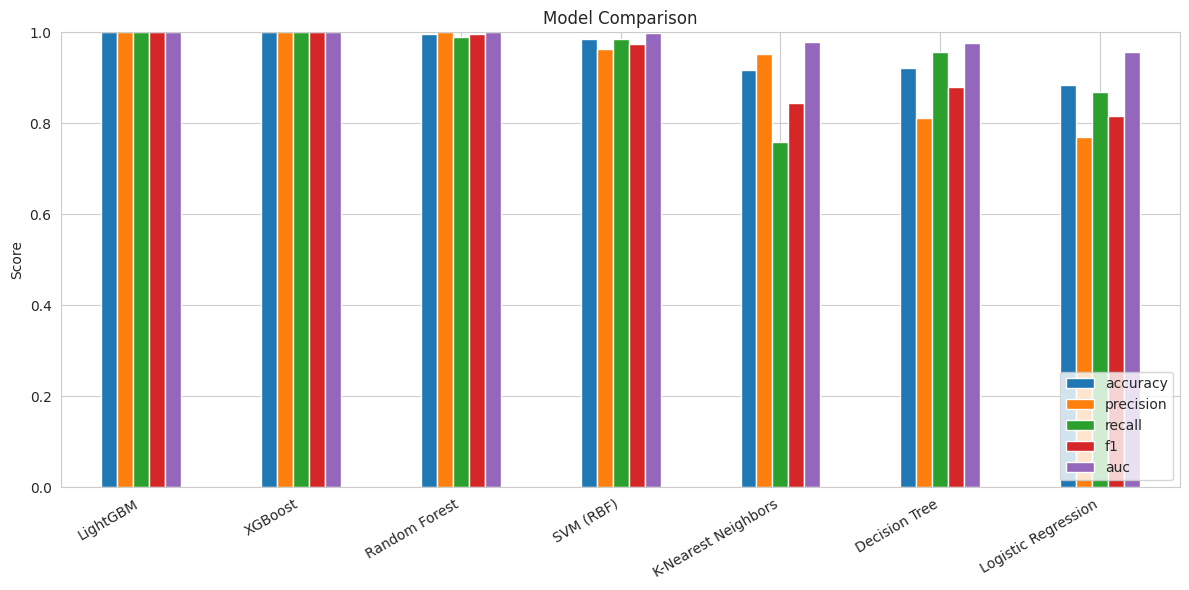

In [38]:
results_df[['accuracy', 'precision', 'recall', 'f1', 'auc']].plot(
    kind='bar', figsize=(12, 6), ylim=(0, 1)
)
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [39]:
best_name = results_df.index[0]
print(f"Best model by AUC: {best_name}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

if best_name == 'XGBoost':
    base = XGBClassifier(scale_pos_weight=pos_weight, eval_metric='logloss', random_state=RANDOM_STATE)
    param_grid = {
        'n_estimators': [200, 300, 500], 'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1], 'subsample': [0.8, 1.0]
    }
elif best_name == 'LightGBM':
    base = LGBMClassifier(scale_pos_weight=pos_weight, random_state=RANDOM_STATE, verbosity=-1)
    param_grid = {
        'n_estimators': [200, 300, 500], 'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1], 'num_leaves': [15, 31, 63]
    }
elif best_name == 'Random Forest':
    base = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE)
    param_grid = {
        'n_estimators': [200, 300, 500], 'max_depth': [None, 6, 10],
        'min_samples_split': [2, 5, 10]
    }
elif best_name == 'SVM (RBF)':
    base = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE)
    param_grid = {'C': [0.1, 1, 10], 'gamma': ['scale', 0.01, 0.1]}
elif best_name == 'Decision Tree':
    base = DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE)
    param_grid = {'max_depth': [4, 6, 8, 10], 'min_samples_split': [2, 5, 10]}
else:  # Logistic Regression / KNN fallback
    base = fitted_models[best_name]
    param_grid = {}

if param_grid:
    grid = GridSearchCV(base, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)
    grid.fit(X_train_scaled, y_train)
    print("Best params:", grid.best_params_)
    print("Best CV AUC:", grid.best_score_)
    best_model = grid.best_estimator_
else:
    best_model = base
    print("Using default-tuned model (no grid defined for this type).")

Best model by AUC: LightGBM
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best params: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300, 'num_leaves': 31}
Best CV AUC: 0.9998171699698254


**Check duplicate records**

In [40]:
preds = best_model.predict(X_test_scaled)
probs = best_model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy: ", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall:   ", recall_score(y_test, preds))
print("F1 Score: ", f1_score(y_test, preds))
print("AUC-ROC:  ", roc_auc_score(y_test, probs))
print()
print(classification_report(y_test, preds))

Accuracy:  0.9971910112359551
Precision: 0.9906542056074766
Recall:    1.0
F1 Score:  0.9953051643192489
AUC-ROC:   0.9999622641509434

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       500
           1       0.99      1.00      1.00       212

    accuracy                           1.00       712
   macro avg       1.00      1.00      1.00       712
weighted avg       1.00      1.00      1.00       712



**Clean column names**

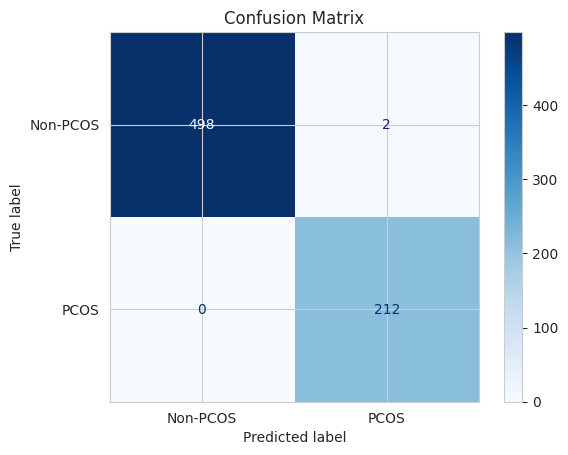

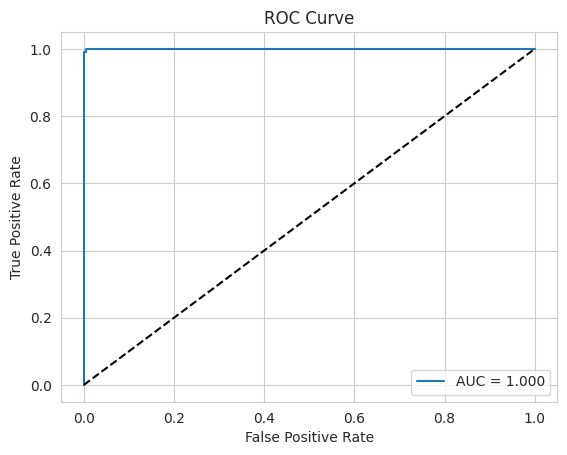

In [41]:
cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(cm, display_labels=['Non-PCOS', 'PCOS']).plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

fpr, tpr, _ = roc_curve(y_test, probs)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, probs):.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

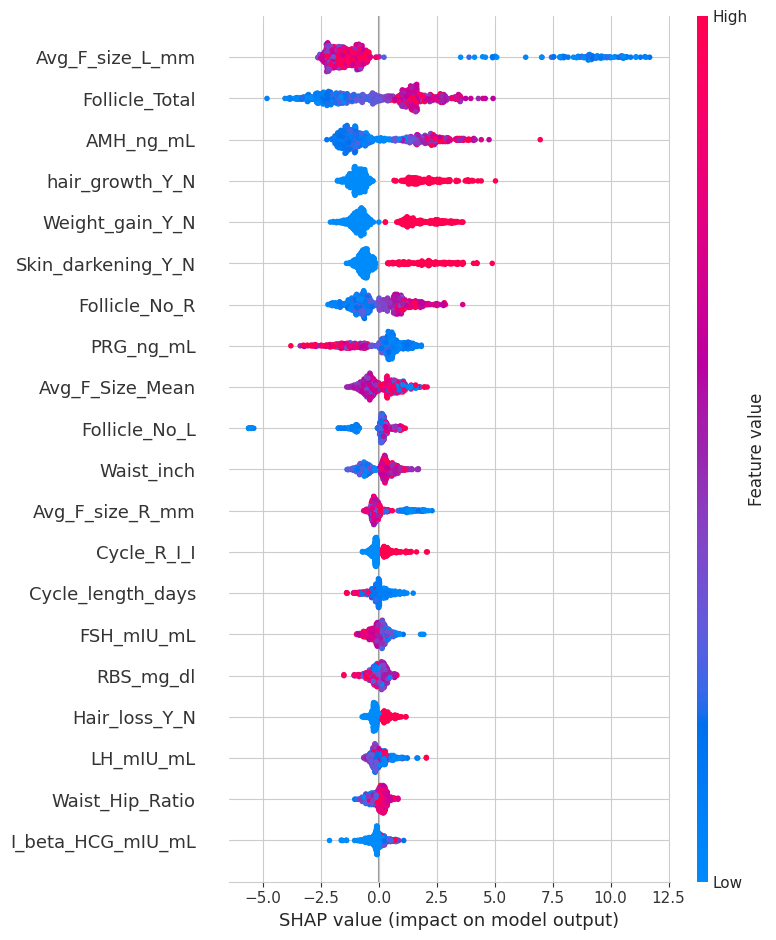

In [42]:
import shap

tree_based = ['Random Forest', 'XGBoost', 'LightGBM', 'Decision Tree']

if best_name in tree_based:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_scaled)
else:
    # Model-agnostic explainer for Logistic Regression / SVM / KNN (slower — uses a background sample)
    background = shap.sample(X_train_scaled, 100, random_state=RANDOM_STATE)
    explainer = shap.KernelExplainer(best_model.predict_proba, background)
    shap_values = explainer.shap_values(X_test_scaled.sample(100, random_state=RANDOM_STATE))

shap.summary_plot(shap_values, X_test_scaled if best_name in tree_based else X_test_scaled.sample(100, random_state=RANDOM_STATE), show=True)

In [43]:
import os
os.makedirs('/content/drive/MyDrive/PCOS/artifacts', exist_ok=True) if 'drive' in dir() else os.makedirs('artifacts', exist_ok=True)

SAVE_DIR = '/content/drive/MyDrive/PCOS/artifacts' if 'drive' in dir() else 'artifacts'

joblib.dump(best_model, f'{SAVE_DIR}/structured_model.joblib')
joblib.dump(scaler, f'{SAVE_DIR}/structured_scaler.joblib')
joblib.dump(imputer, f'{SAVE_DIR}/structured_imputer.joblib')
joblib.dump(list(X.columns), f'{SAVE_DIR}/structured_columns.joblib')

print("Saved to:", SAVE_DIR)

Saved to: artifacts
